# 02. Целевая переменная и признаки: EDA

**Цель:** исследовать распределение G-spread, связь с ключевыми признаками (Tier 1),
проверить мультиколлинеарность и сравнить Cbonds vs РСБУ-метрики.

**Входные данные:** `../data/panel.csv` -- 295 569 строк, 967 облигаций, 34 признака.

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path

# ---------- style ----------
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

FIG_DIR = Path('../notebooks/figures')
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(name: str, fig=None):
    """Save current figure to FIG_DIR with 02_ prefix."""
    target = FIG_DIR / f'02_{name}.png'
    (fig or plt.gcf()).savefig(target)
    print(f'Saved: {target}')

print('Setup OK')

Setup OK


## 2. Load data

In [2]:
DATA_PATH = Path("../../data/panel.csv")

df = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Shape: {df.shape}')
print(f'Bonds: {df["isin"].nunique()}')
print(f'Date range: {df["date"].min().date()} -- {df["date"].max().date()}')
df.head(3)

Shape: (295569, 34)
Bonds: 967
Date range: 2020-01-03 -- 2026-03-30


,date,isin,g_spread,duration,rating_numeric,net_debt_ebitda,ebitda_margin,ebitda_yoy,revenue_yoy,debt_to_equity,...,issue_volume_rub,imoex_return,volume_ma20,coupon_rate,age_days,imoex_realized_vol,time_to_maturity,coupon_frequency,is_state_owned,issuer_name
0,2020-01-03,RU000A0JSGV0,4.672847,0.501370,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000e+10,1.001356,565109.8,9.80,2723,NaN,4557.0,2,0,"""Российские ЖД"" ОАО 32 обл."
1,2020-01-03,RU000A0JSQ58,2.798600,0.071233,1.0,NaN,NaN,NaN,NaN,NaN,...,1.000000e+10,1.001356,200723.2,12.00,2704,NaN,2756.0,2,1,ФСК Россети(ПАО)-обл. сер.22
2,2020-01-03,RU000A0JWV63,3.899662,4.630137,3.0,NaN,NaN,NaN,NaN,NaN,...,5.000000e+09,1.001356,1096529.9,14.25,1185,NaN,NaN,2,0,"""Россельхозбанк"" (АО) обл.08Т1"


In [3]:
# Tier 1 features
TIER1 = [
    'duration', 'rating_numeric', 'net_debt_ebitda',
    'key_rate', 'ofz_slope', 'rvi',
    'oil_brent', 'usdrub', 'sector', 'issue_volume_rub',
]
TIER1_NUMERIC = [c for c in TIER1 if c != 'sector']

print('Missing values in Tier 1 features:')
df[TIER1].isnull().sum().to_frame('n_missing').assign(
    pct=lambda x: (x['n_missing'] / len(df) * 100).round(1)
)

Missing values in Tier 1 features:


,n_missing,pct
duration,0,0.0
rating_numeric,50510,17.1
net_debt_ebitda,235342,79.6
key_rate,0,0.0
ofz_slope,0,0.0
rvi,0,0.0
oil_brent,0,0.0
usdrub,0,0.0
sector,35526,12.0
issue_volume_rub,0,0.0


## 3. Распределение целевой переменной (g_spread)

Saved: /repo/notebooks/figures/02_target_histogram.png


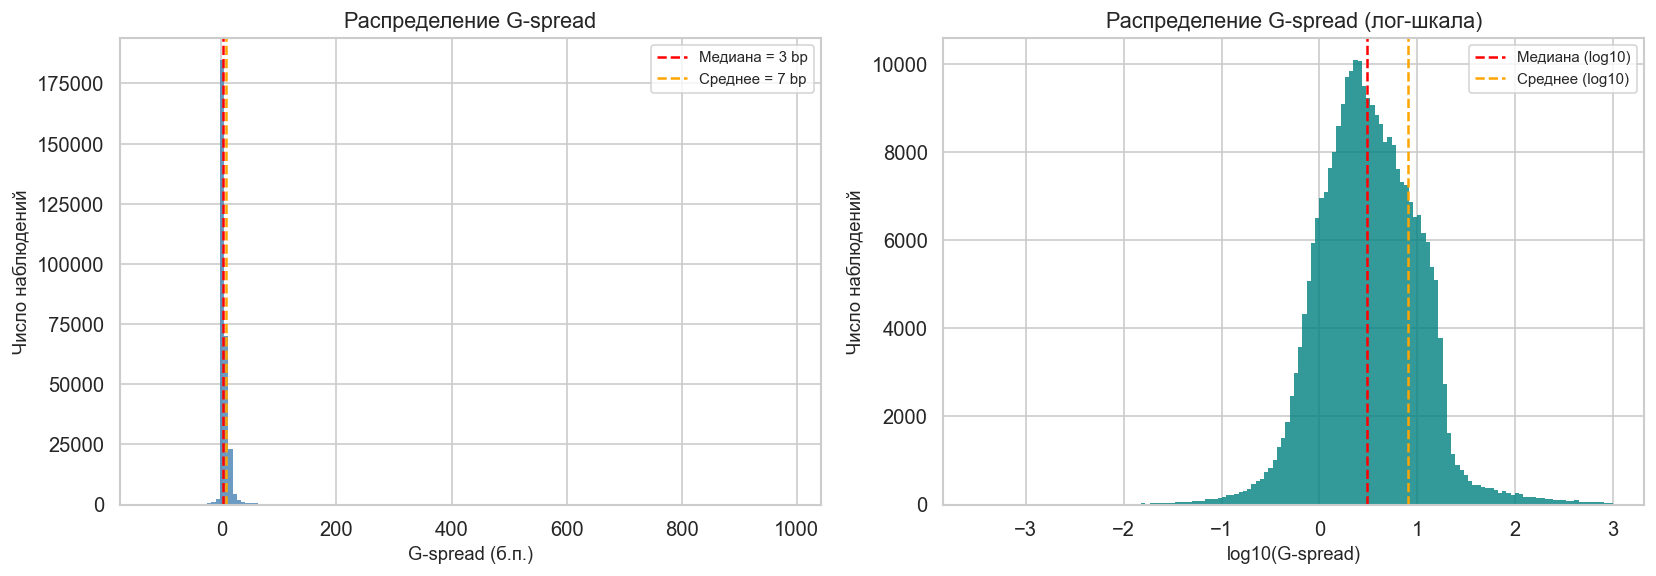

In [4]:
gs = df['g_spread'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- raw histogram ---
ax = axes[0]
ax.hist(gs, bins=150, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(gs.median(), color='red', ls='--', lw=1.5, label=f'Медиана = {gs.median():.0f} bp')
ax.axvline(gs.mean(), color='orange', ls='--', lw=1.5, label=f'Среднее = {gs.mean():.0f} bp')
ax.set_xlabel('G-spread (б.п.)')
ax.set_ylabel('Число наблюдений')
ax.set_title('Распределение G-spread')
ax.legend(fontsize=9)

# --- log-scale histogram ---
ax = axes[1]
gs_pos = gs[gs > 0]
ax.hist(np.log10(gs_pos), bins=150, color='teal', edgecolor='none', alpha=0.8)
ax.axvline(np.log10(gs_pos.median()), color='red', ls='--', lw=1.5, label=f'Медиана (log10)')
ax.axvline(np.log10(gs_pos.mean()), color='orange', ls='--', lw=1.5, label=f'Среднее (log10)')
ax.set_xlabel('log10(G-spread)')
ax.set_ylabel('Число наблюдений')
ax.set_title('Распределение G-spread (лог-шкала)')
ax.legend(fontsize=9)

fig.tight_layout()
savefig('target_histogram')
plt.show()

In [5]:
# Quantile table
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
qtable = gs.quantile(quantiles).to_frame('g_spread_bp')
qtable.index = [f'{int(q*100)}%' for q in quantiles]
qtable['g_spread_bp'] = qtable['g_spread_bp'].round(1)
print('Квантили G-spread (б.п.):')
qtable

Квантили G-spread (б.п.):


,g_spread_bp
1%,-7.6
5%,0.1
25%,1.3
50%,2.9
75%,6.8
95%,17.9
99%,84.1


Saved: /repo/notebooks/figures/02_target_boxplot.png


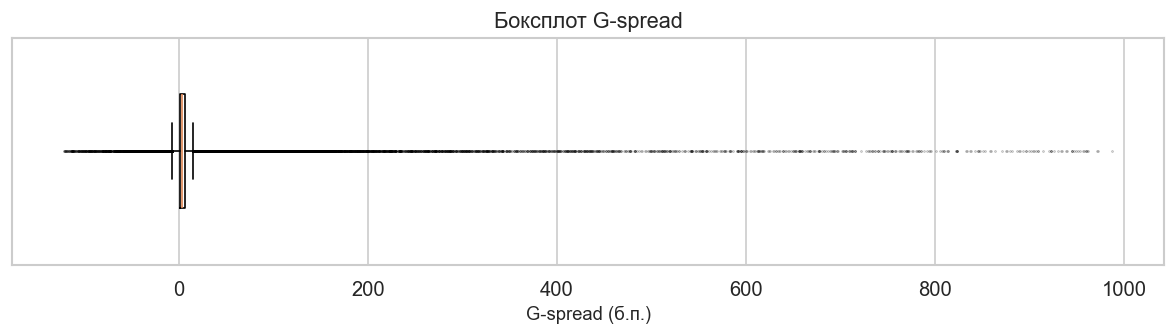

In [6]:
# Box plot
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(gs, vert=False, widths=0.5,
           flierprops=dict(marker='.', markersize=1, alpha=0.3))
ax.set_xlabel('G-spread (б.п.)')
ax.set_title('Боксплот G-spread')
ax.set_yticks([])
fig.tight_layout()
savefig('target_boxplot')
plt.show()

Saved: /repo/notebooks/figures/02_target_cdf.png


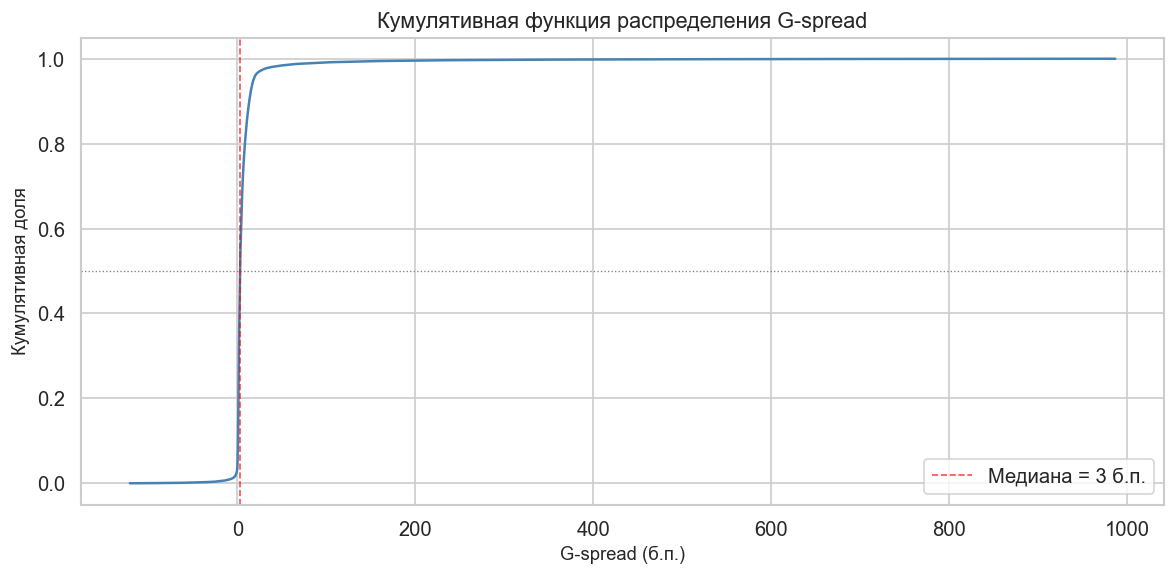

In [7]:
# Cumulative distribution
fig, ax = plt.subplots(figsize=(10, 5))
sorted_gs = np.sort(gs.values)
cdf = np.arange(1, len(sorted_gs) + 1) / len(sorted_gs)
ax.plot(sorted_gs, cdf, color='steelblue', lw=1.5)
ax.axhline(0.5, color='grey', ls=':', lw=0.8)
ax.axvline(gs.median(), color='red', ls='--', lw=1, alpha=0.7,
           label=f'Медиана = {gs.median():.0f} б.п.')
ax.set_xlabel('G-spread (б.п.)')
ax.set_ylabel('Кумулятивная доля')
ax.set_title('Кумулятивная функция распределения G-spread')
ax.legend()
fig.tight_layout()
savefig('target_cdf')
plt.show()

## 4. G-spread по группам

Saved: /repo/notebooks/figures/02_gspread_by_rating.png


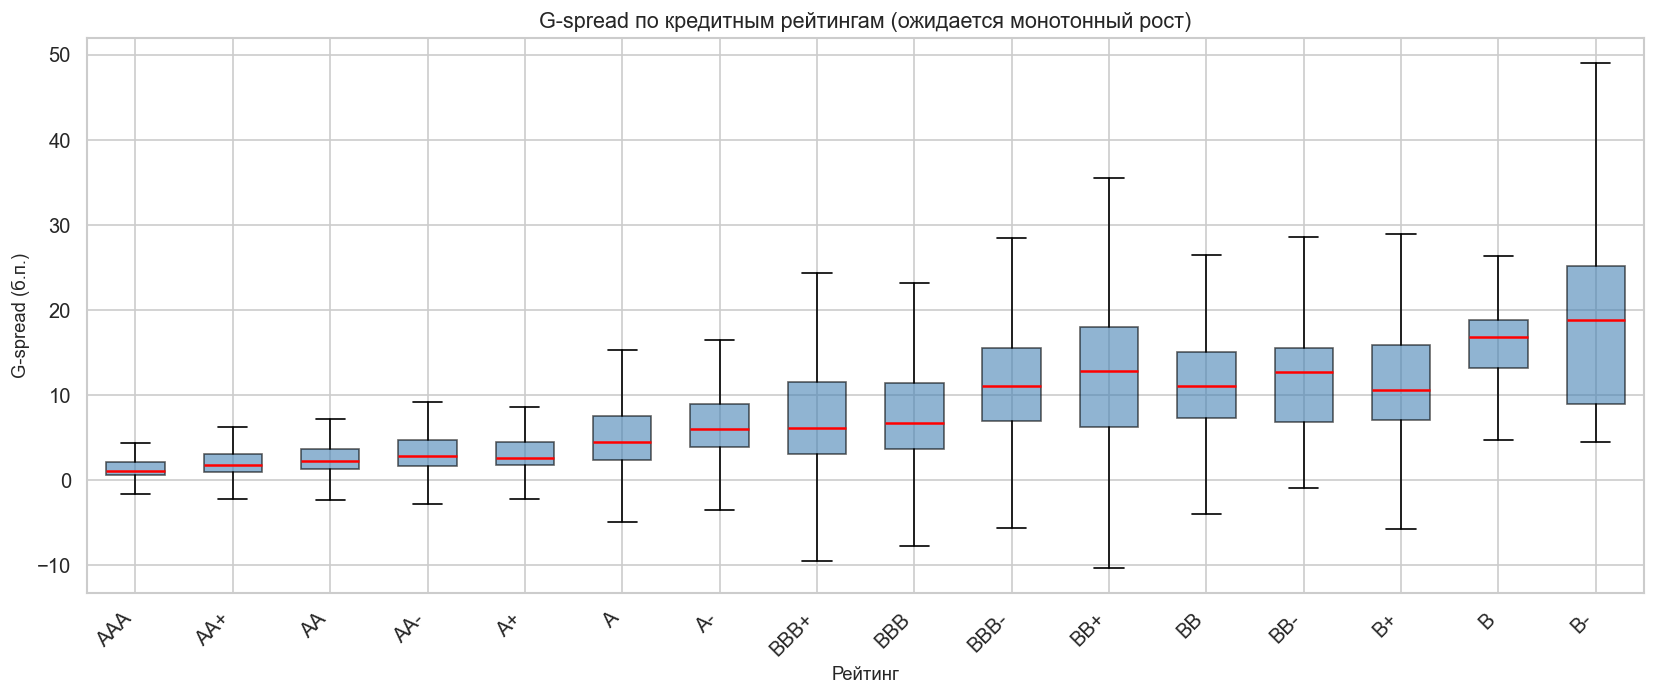

In [8]:
# 4.1 By rating (boxplot, x-axis = rating_numeric 1..20)
df_rated = df.dropna(subset=['rating_numeric', 'g_spread']).copy()
df_rated['rating_int'] = df_rated['rating_numeric'].astype(int)

# Rating label mapping (1=AAA ... 20=D)
RATING_LABELS = {
    1: 'AAA', 2: 'AA+', 3: 'AA', 4: 'AA-',
    5: 'A+', 6: 'A', 7: 'A-',
    8: 'BBB+', 9: 'BBB', 10: 'BBB-',
    11: 'BB+', 12: 'BB', 13: 'BB-',
    14: 'B+', 15: 'B', 16: 'B-',
    17: 'CCC+', 18: 'CCC', 19: 'CC', 20: 'D',
}

ratings_present = sorted(df_rated['rating_int'].unique())

fig, ax = plt.subplots(figsize=(14, 6))
data_by_rating = [df_rated.loc[df_rated['rating_int'] == r, 'g_spread'].values
                  for r in ratings_present]
bp = ax.boxplot(data_by_rating, positions=ratings_present, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color='red', lw=1.5))
for patch in bp['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)

ax.set_xticks(ratings_present)
ax.set_xticklabels([RATING_LABELS.get(r, str(r)) for r in ratings_present],
                    rotation=45, ha='right')
ax.set_xlabel('Рейтинг')
ax.set_ylabel('G-spread (б.п.)')
ax.set_title('G-spread по кредитным рейтингам (ожидается монотонный рост)')
fig.tight_layout()
savefig('gspread_by_rating')
plt.show()

Saved: /repo/notebooks/figures/02_gspread_by_sector.png


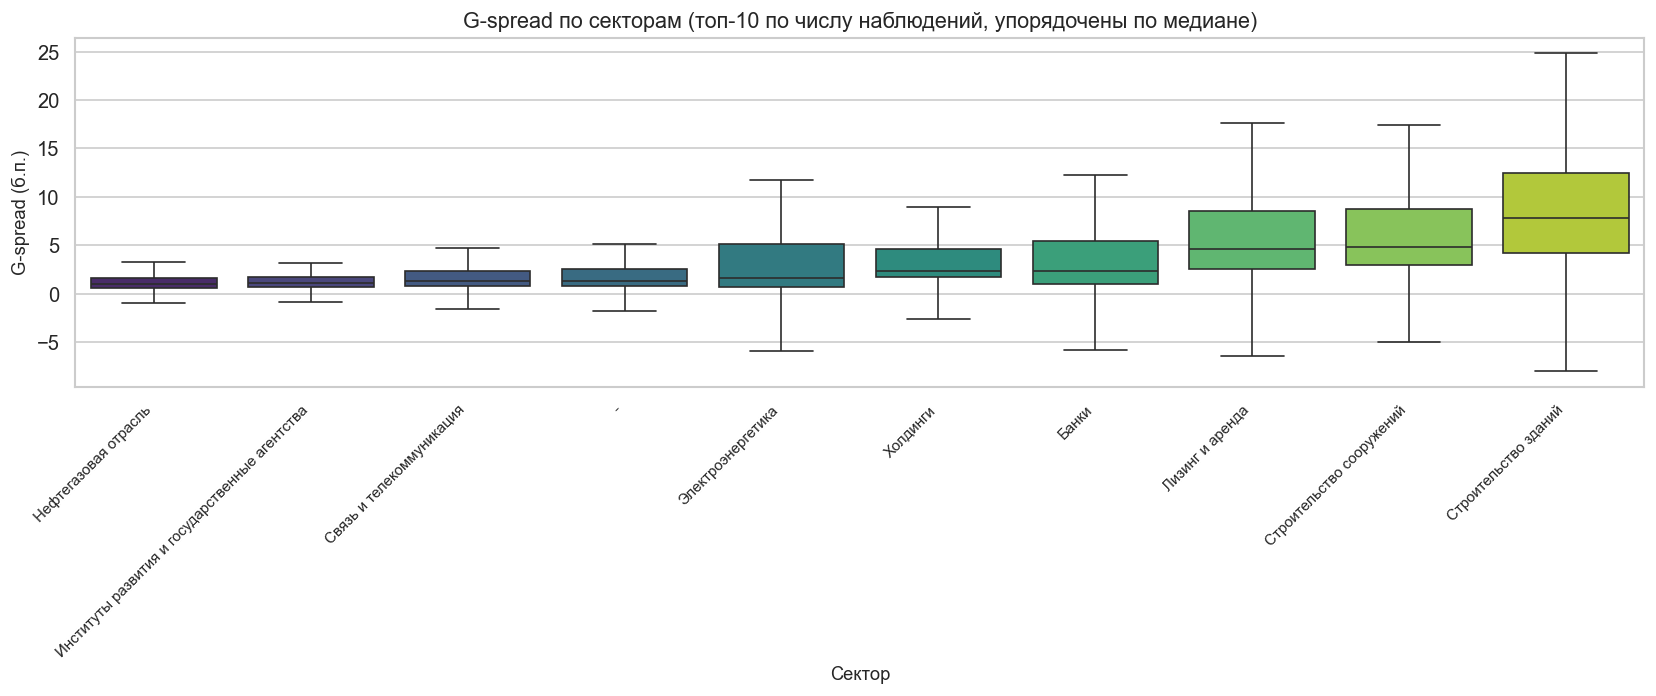

In [9]:
# 4.2 By sector (top-10 by count, ordered by median g_spread)
df_sec = df.dropna(subset=['sector', 'g_spread']).copy()
top10_sectors = df_sec['sector'].value_counts().head(10).index.tolist()
df_sec_top = df_sec[df_sec['sector'].isin(top10_sectors)].copy()

# Order by median g_spread
sector_order = (df_sec_top.groupby('sector')['g_spread']
                .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_sec_top, x='sector', y='g_spread',
            order=sector_order, showfliers=False, ax=ax,
            palette='viridis')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Сектор')
ax.set_ylabel('G-spread (б.п.)')
ax.set_title('G-spread по секторам (топ-10 по числу наблюдений, упорядочены по медиане)')
fig.tight_layout()
savefig('gspread_by_sector')
plt.show()

Saved: /repo/notebooks/figures/02_gspread_by_ownership.png


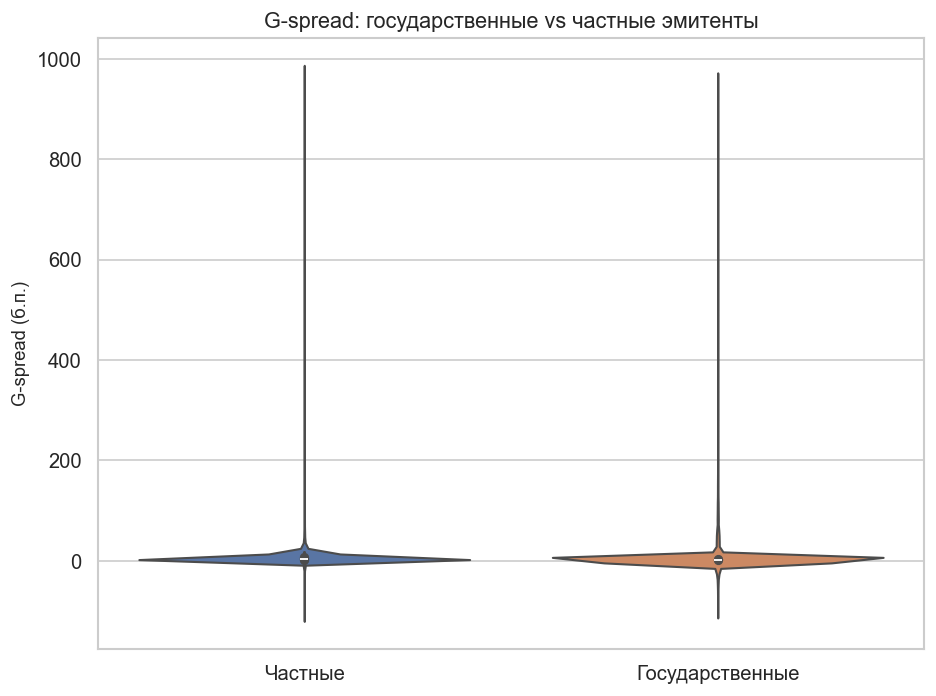

In [10]:
# 4.3 By is_state_owned (violin plot)
df_state = df.dropna(subset=['is_state_owned', 'g_spread']).copy()
df_state['ownership'] = df_state['is_state_owned'].map({0: 'Частные', 1: 'Государственные'})

fig, ax = plt.subplots(figsize=(8, 6))
sns.violinplot(data=df_state, x='ownership', y='g_spread',
               palette=['#4C72B0', '#DD8452'], cut=0, ax=ax)
ax.set_xlabel('')
ax.set_ylabel('G-spread (б.п.)')
ax.set_title('G-spread: государственные vs частные эмитенты')
fig.tight_layout()
savefig('gspread_by_ownership')
plt.show()

Saved: /repo/notebooks/figures/02_gspread_by_duration_bucket.png


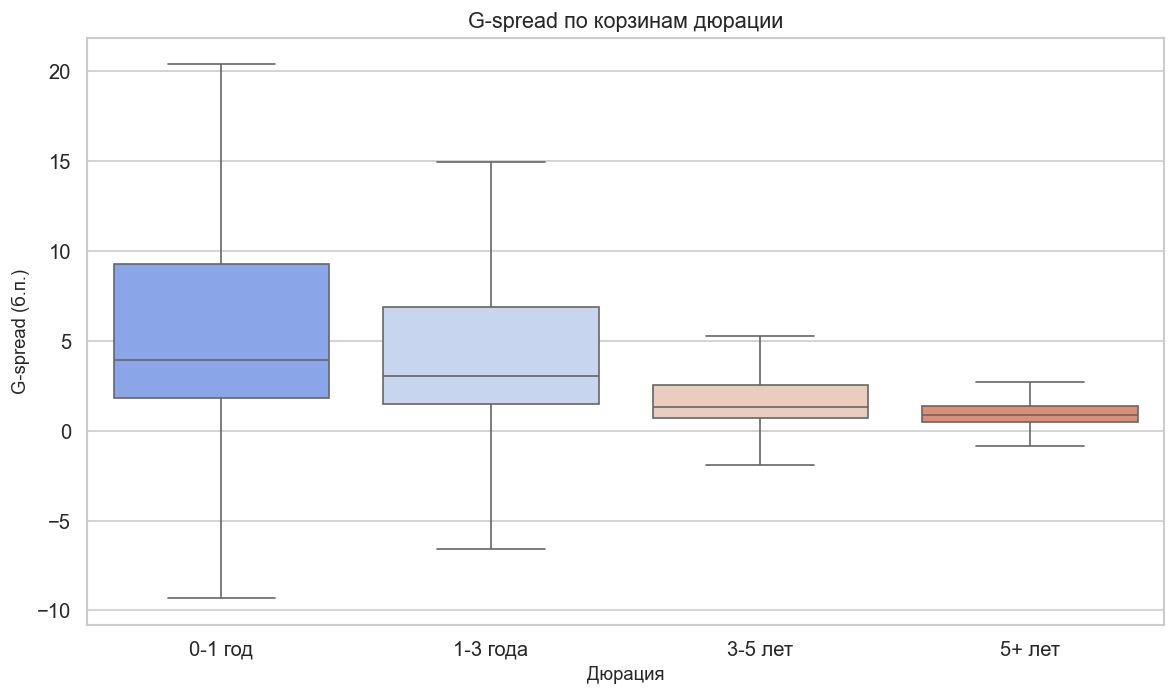

In [11]:
# 4.4 By duration bucket
df_dur = df.dropna(subset=['duration', 'g_spread']).copy()
bins = [0, 1, 3, 5, df_dur['duration'].max() + 1]
labels = ['0-1 год', '1-3 года', '3-5 лет', '5+ лет']
df_dur['dur_bucket'] = pd.cut(df_dur['duration'], bins=bins, labels=labels, right=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_dur, x='dur_bucket', y='g_spread',
            order=labels, showfliers=False, palette='coolwarm', ax=ax)
ax.set_xlabel('Дюрация')
ax.set_ylabel('G-spread (б.п.)')
ax.set_title('G-spread по корзинам дюрации')
fig.tight_layout()
savefig('gspread_by_duration_bucket')
plt.show()

## 5. Временная динамика G-spread

In [12]:
# Monthly aggregation
df_ts = df.dropna(subset=['g_spread']).copy()
df_ts['month'] = df_ts['date'].dt.to_period('M')

monthly = df_ts.groupby('month')['g_spread'].agg(['median', 
    lambda x: x.quantile(0.25), 
    lambda x: x.quantile(0.75)]).reset_index()
monthly.columns = ['month', 'median', 'q25', 'q75']
monthly['month_dt'] = monthly['month'].dt.to_timestamp()

# Monthly macro
macro_monthly = df_ts.groupby('month')[['key_rate', 'rvi']].median().reset_index()
macro_monthly['month_dt'] = macro_monthly['month'].dt.to_timestamp()

merged = monthly.merge(macro_monthly, on='month_dt', suffixes=('', '_macro'))

Saved: /repo/notebooks/figures/02_temporal_gspread_keyrate.png


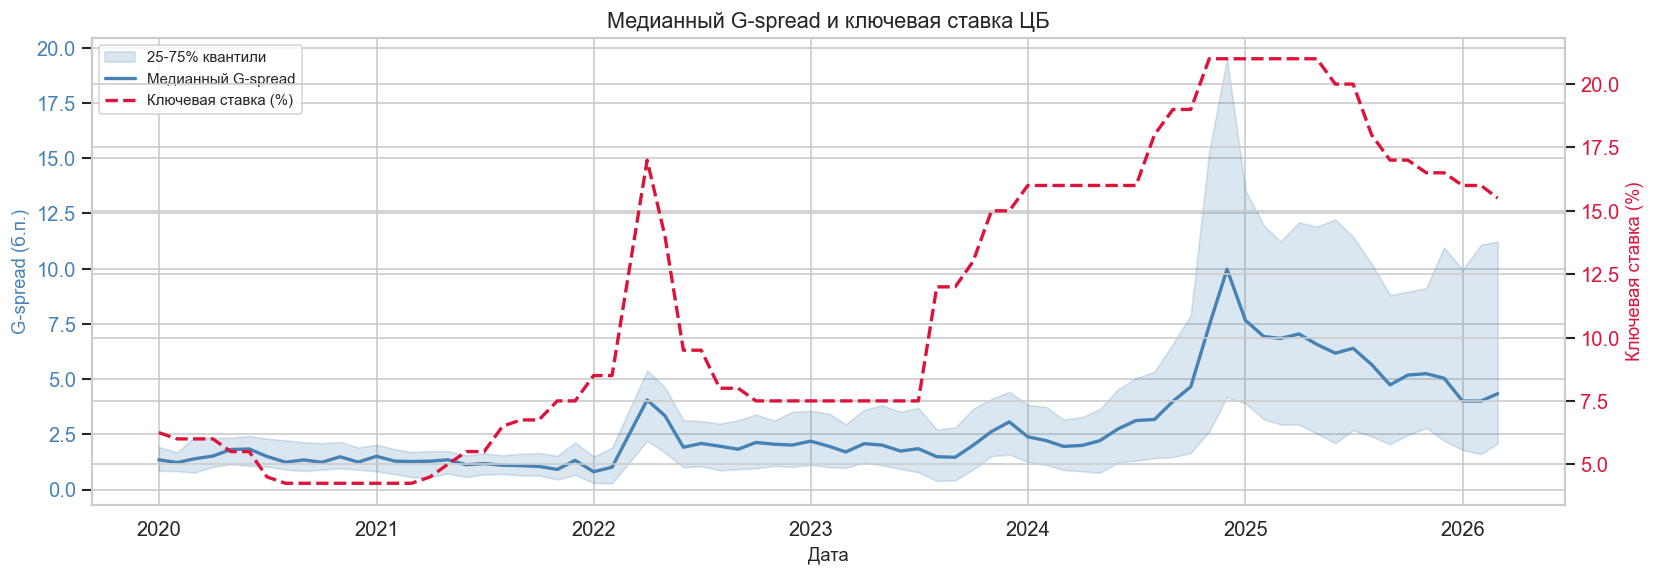

In [13]:
# Plot 1: G-spread + key_rate
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(merged['month_dt'], merged['q25'], merged['q75'],
                 alpha=0.2, color='steelblue', label='25-75% квантили')
ax1.plot(merged['month_dt'], merged['median'], color='steelblue',
         lw=2, label='Медианный G-spread')
ax1.set_xlabel('Дата')
ax1.set_ylabel('G-spread (б.п.)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(merged['month_dt'], merged['key_rate'], color='crimson',
         lw=2, ls='--', label='Ключевая ставка (%)')
ax2.set_ylabel('Ключевая ставка (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Медианный G-spread и ключевая ставка ЦБ')
fig.tight_layout()
savefig('temporal_gspread_keyrate')
plt.show()

Saved: /repo/notebooks/figures/02_temporal_gspread_rvi.png


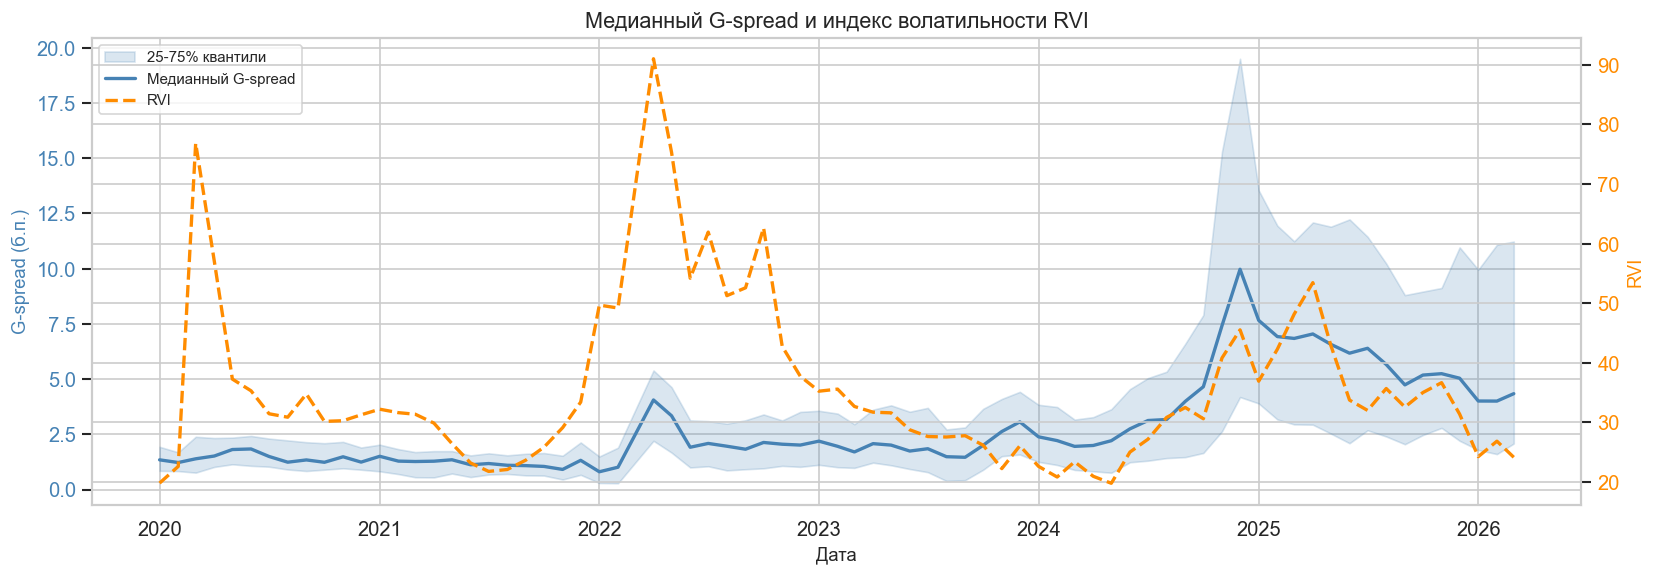

In [14]:
# Plot 2: G-spread + RVI
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(merged['month_dt'], merged['q25'], merged['q75'],
                 alpha=0.2, color='steelblue', label='25-75% квантили')
ax1.plot(merged['month_dt'], merged['median'], color='steelblue',
         lw=2, label='Медианный G-spread')
ax1.set_xlabel('Дата')
ax1.set_ylabel('G-spread (б.п.)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(merged['month_dt'], merged['rvi'], color='darkorange',
         lw=2, ls='--', label='RVI')
ax2.set_ylabel('RVI', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
ax1.set_title('Медианный G-spread и индекс волатильности RVI')
fig.tight_layout()
savefig('temporal_gspread_rvi')
plt.show()

Saved: /repo/notebooks/figures/02_temporal_gspread_by_rating.png


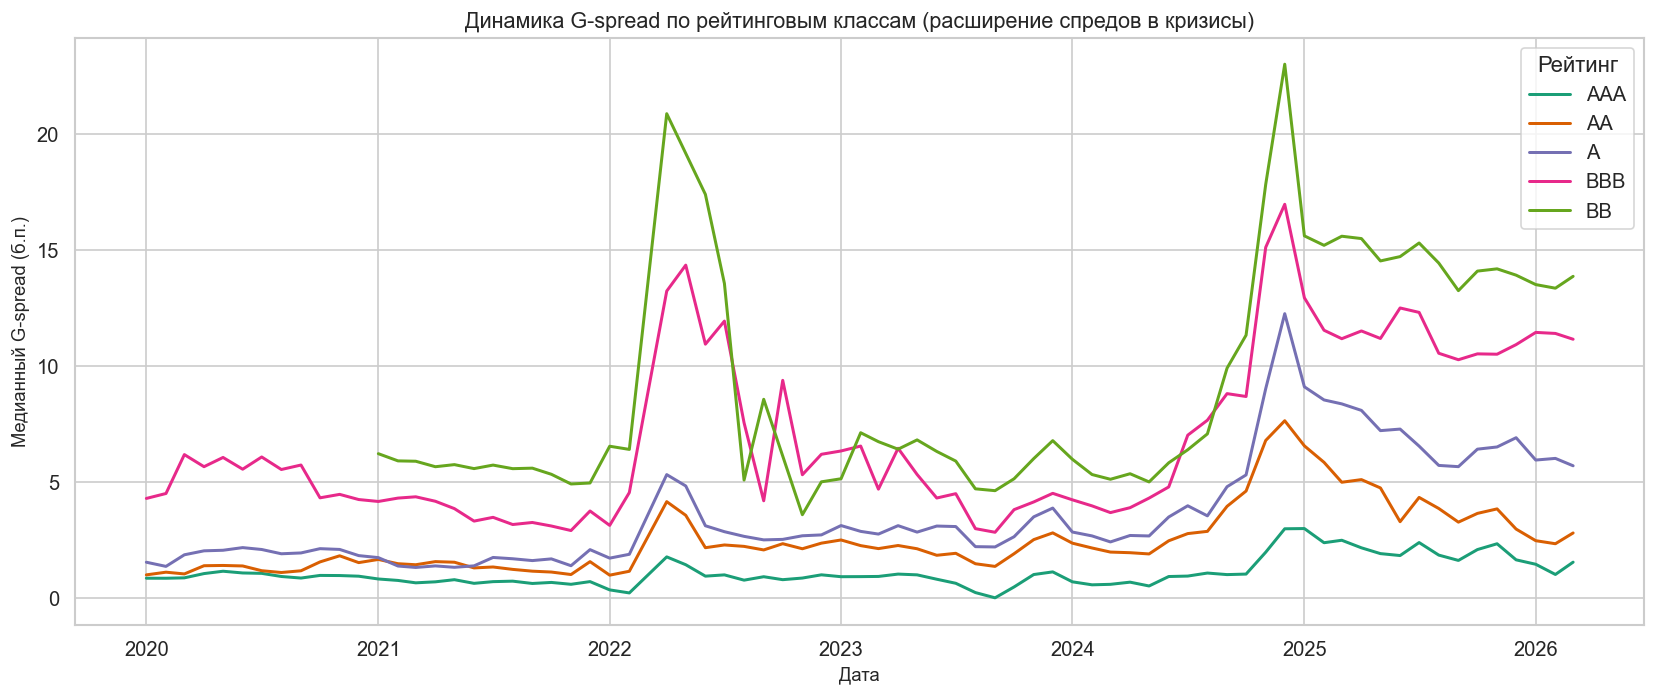

In [15]:
# Rating-grade time series (AAA, AA, A, BBB, BB)
grade_map = {
    'AAA': [1],
    'AA': [2, 3, 4],
    'A': [5, 6, 7],
    'BBB': [8, 9, 10],
    'BB': [11, 12, 13],
}

df_rts = df.dropna(subset=['rating_numeric', 'g_spread']).copy()
df_rts['rating_int'] = df_rts['rating_numeric'].astype(int)
df_rts['month'] = df_rts['date'].dt.to_period('M')

fig, ax = plt.subplots(figsize=(14, 6))
palette = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a', '#66a61e']

for i, (grade, nums) in enumerate(grade_map.items()):
    sub = df_rts[df_rts['rating_int'].isin(nums)]
    ts = sub.groupby('month')['g_spread'].median().reset_index()
    ts['month_dt'] = ts['month'].dt.to_timestamp()
    ax.plot(ts['month_dt'], ts['g_spread'], lw=1.8, label=grade, color=palette[i])

ax.set_xlabel('Дата')
ax.set_ylabel('Медианный G-spread (б.п.)')
ax.set_title('Динамика G-spread по рейтинговым классам (расширение спредов в кризисы)')
ax.legend(title='Рейтинг')
fig.tight_layout()
savefig('temporal_gspread_by_rating')
plt.show()

## 6. Scatter: G-spread vs Tier 1 признаки

Saved: /repo/notebooks/figures/02_scatter_tier1.png


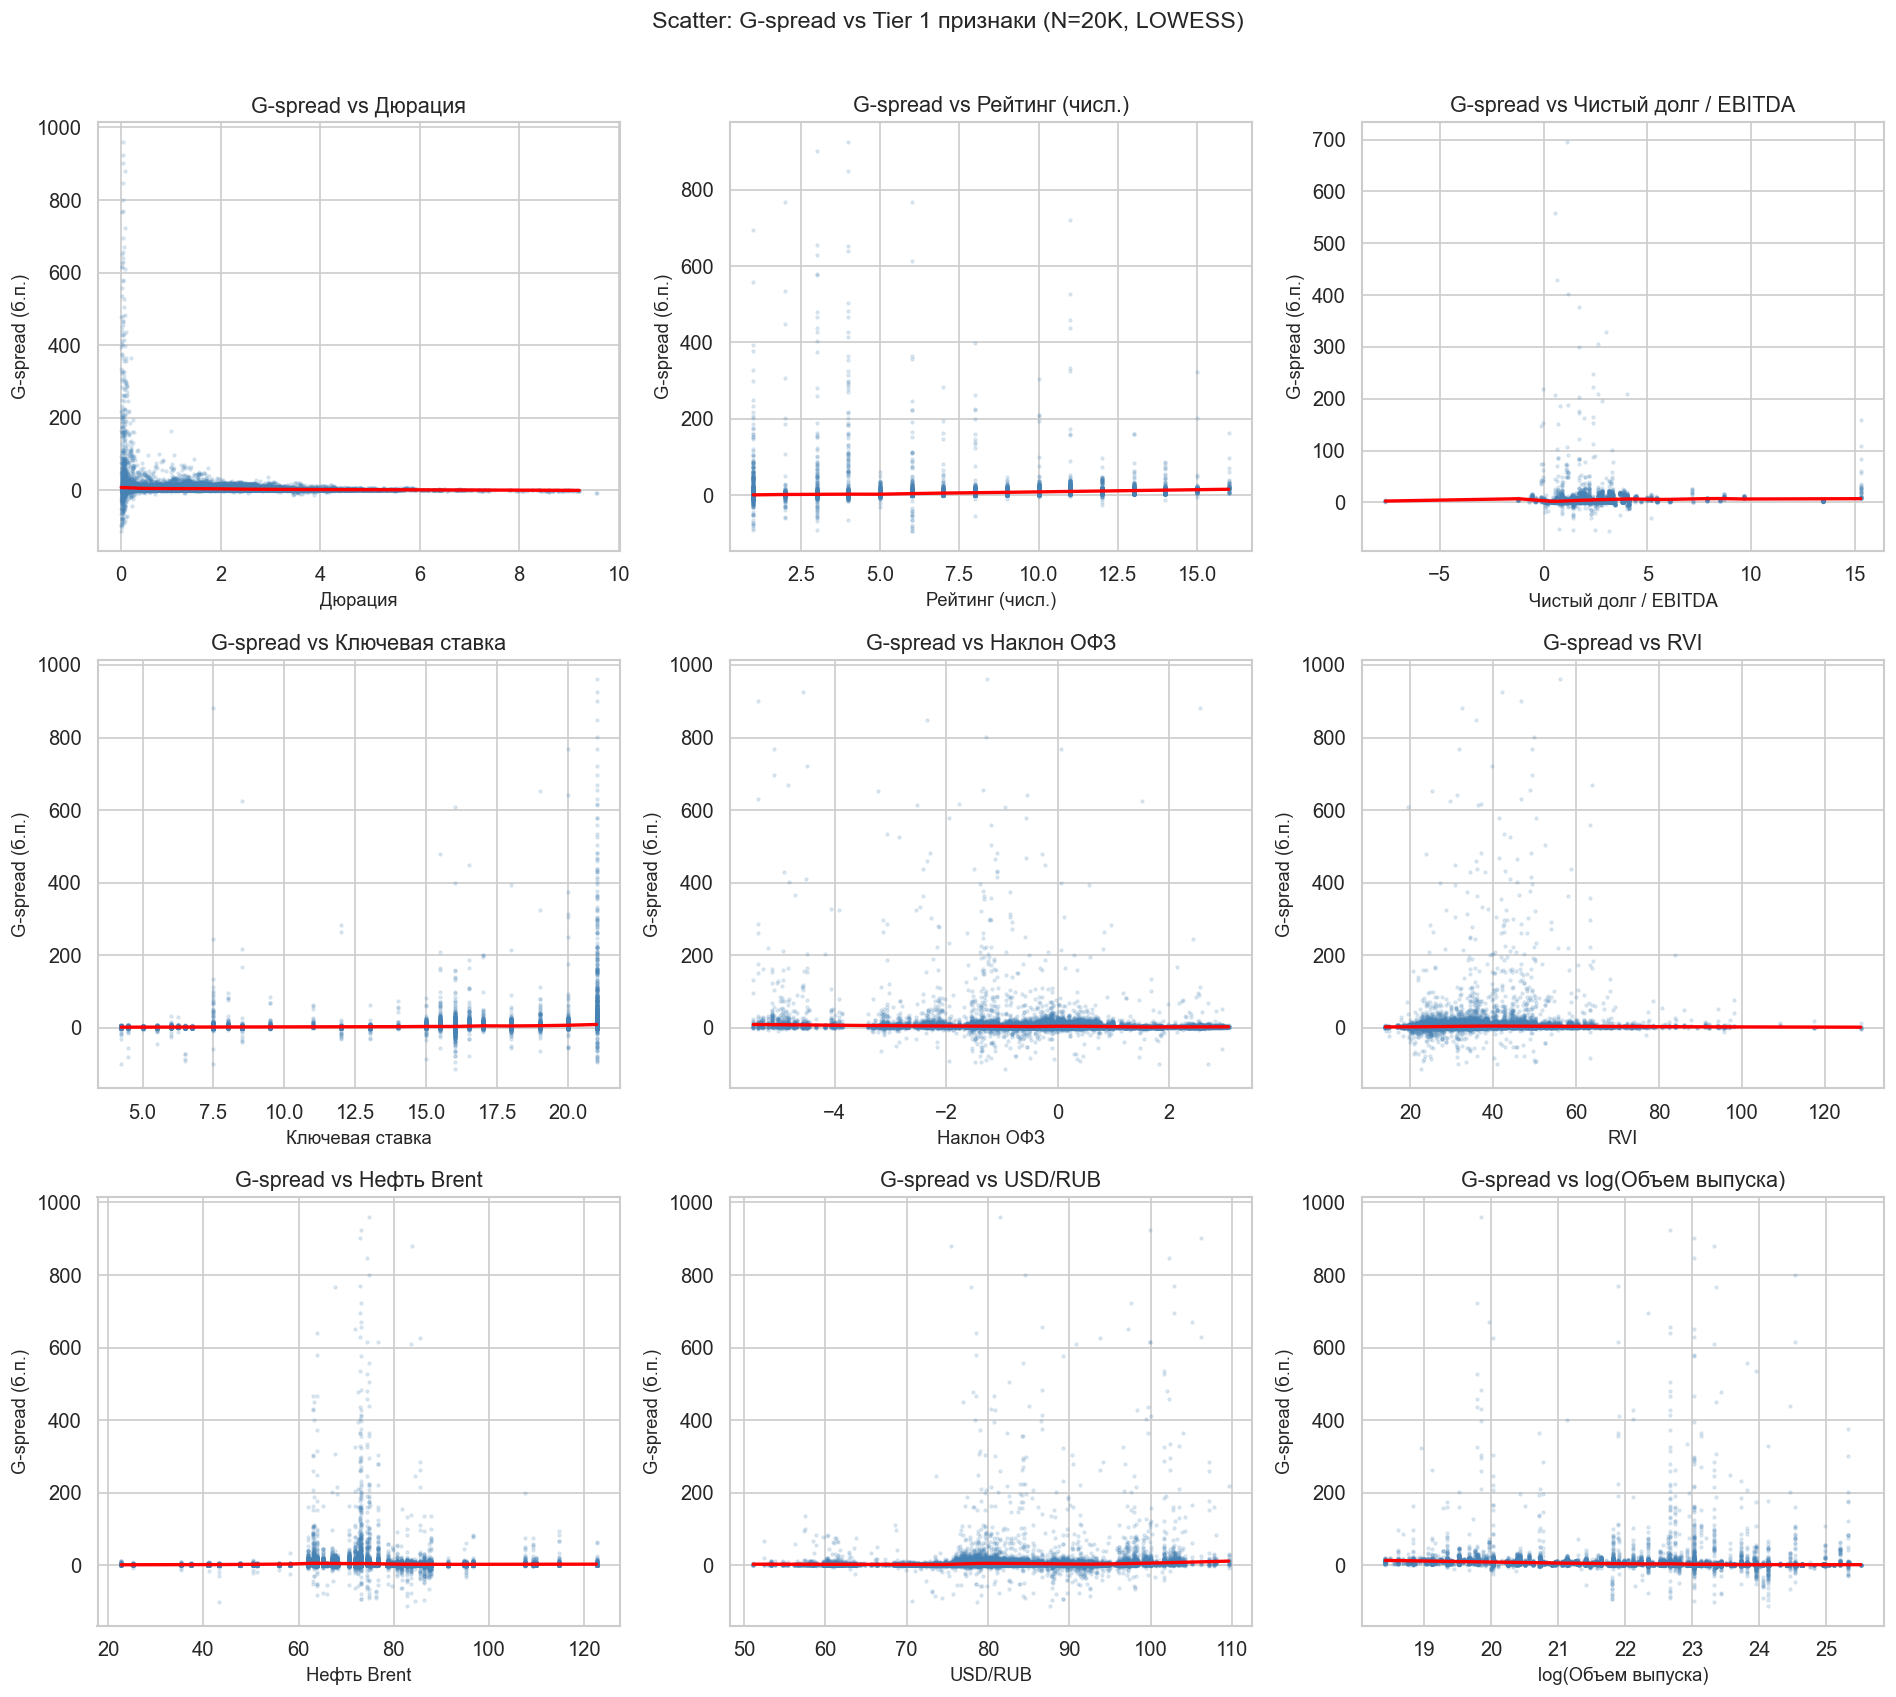

In [16]:
# Subsample for speed
np.random.seed(42)
idx = np.random.choice(len(df), size=min(20_000, len(df)), replace=False)
dfs = df.iloc[idx].copy()
dfs['log_issue_volume'] = np.log1p(dfs['issue_volume_rub'])

scatter_features = [
    ('duration', 'Дюрация'),
    ('rating_numeric', 'Рейтинг (числ.)'),
    ('net_debt_ebitda', 'Чистый долг / EBITDA'),
    ('key_rate', 'Ключевая ставка'),
    ('ofz_slope', 'Наклон ОФЗ'),
    ('rvi', 'RVI'),
    ('oil_brent', 'Нефть Brent'),
    ('usdrub', 'USD/RUB'),
    ('log_issue_volume', 'log(Объем выпуска)'),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for ax, (col, label) in zip(axes.ravel(), scatter_features):
    mask = dfs[[col, 'g_spread']].dropna().index
    x = dfs.loc[mask, col].values
    y = dfs.loc[mask, 'g_spread'].values
    ax.scatter(x, y, s=3, alpha=0.15, color='steelblue', rasterized=True)
    
    # LOWESS
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess
        # Sort for lowess
        sort_idx = np.argsort(x)
        x_sorted, y_sorted = x[sort_idx], y[sort_idx]
        # Subsample for lowess speed if needed
        if len(x_sorted) > 5000:
            step = len(x_sorted) // 5000
            x_lw, y_lw = x_sorted[::step], y_sorted[::step]
        else:
            x_lw, y_lw = x_sorted, y_sorted
        smooth = lowess(y_lw, x_lw, frac=0.3)
        ax.plot(smooth[:, 0], smooth[:, 1], color='red', lw=2, label='LOWESS')
    except Exception:
        pass
    
    ax.set_xlabel(label)
    ax.set_ylabel('G-spread (б.п.)')
    ax.set_title(f'G-spread vs {label}')

fig.suptitle('Scatter: G-spread vs Tier 1 признаки (N=20K, LOWESS)', fontsize=14, y=1.01)
fig.tight_layout()
savefig('scatter_tier1')
plt.show()

## 7. Корреляционные матрицы

Saved: /repo/notebooks/figures/02_corr_pearson.png


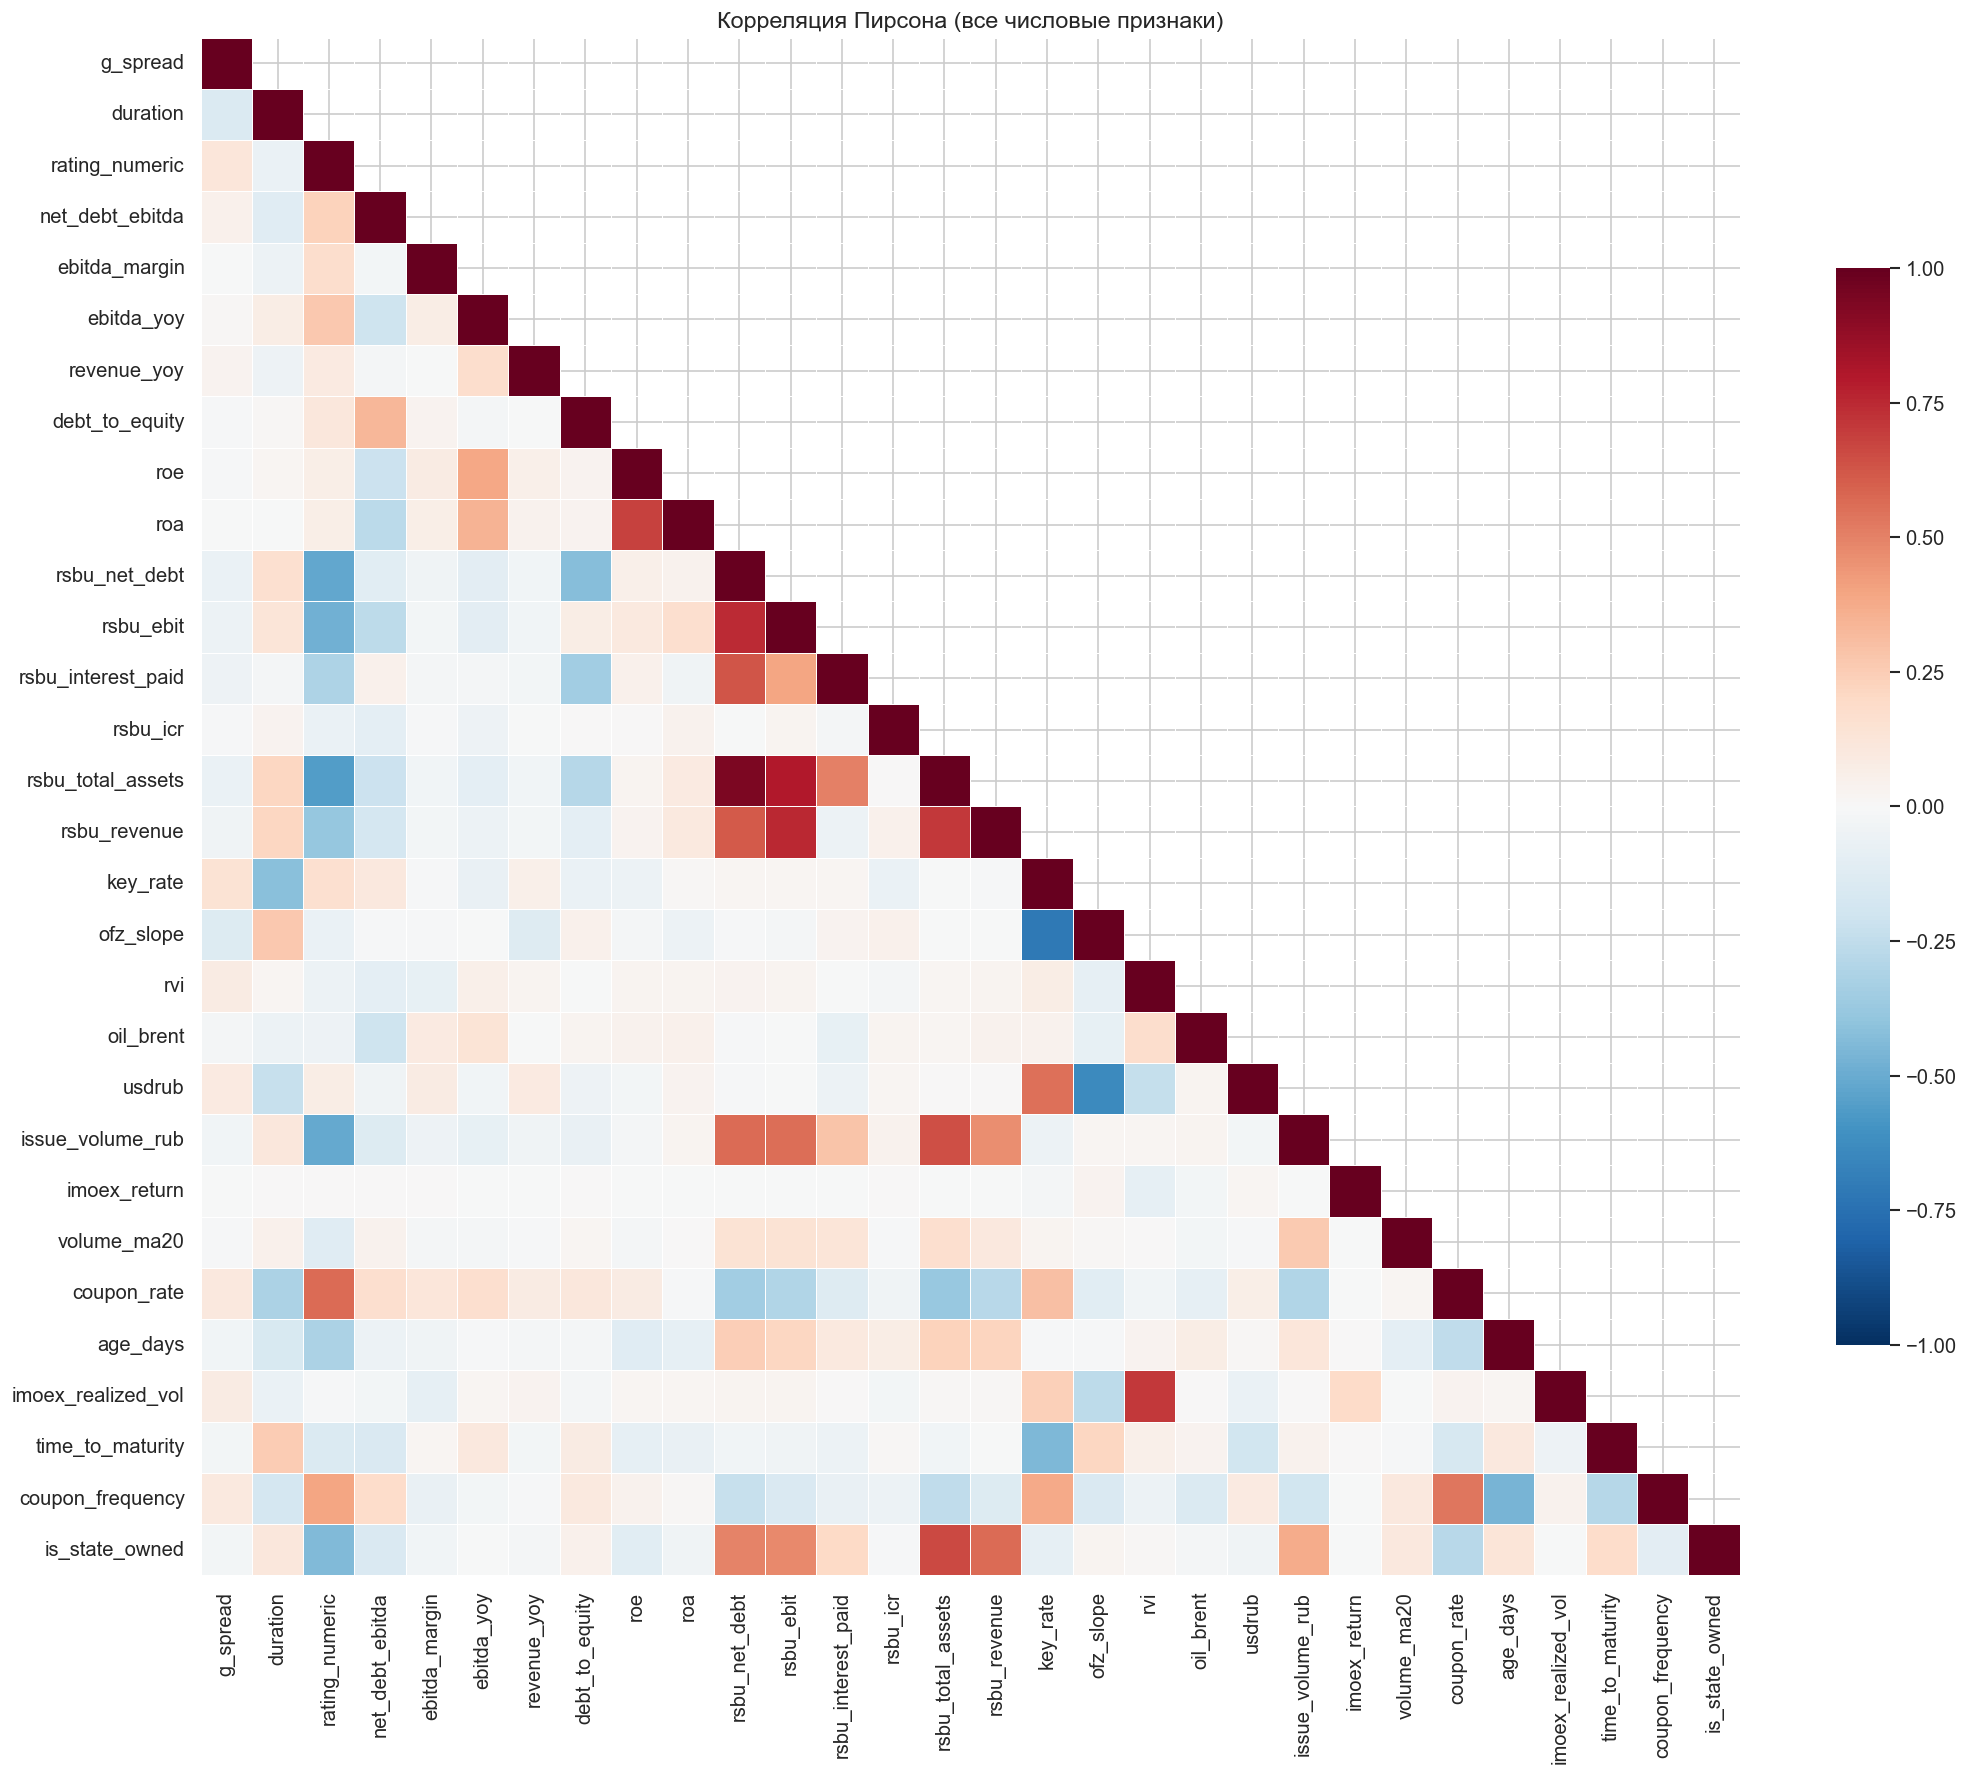

In [17]:
# Select all numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove identifiers / non-informative
exclude = ['isin']
num_cols = [c for c in num_cols if c not in exclude]

corr_df = df[num_cols].copy()

# Pearson
pearson = corr_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(pearson, dtype=bool), k=1)
sns.heatmap(pearson, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Корреляция Пирсона (все числовые признаки)', fontsize=14)
fig.tight_layout()
savefig('corr_pearson')
plt.show()

Saved: /repo/notebooks/figures/02_corr_spearman.png


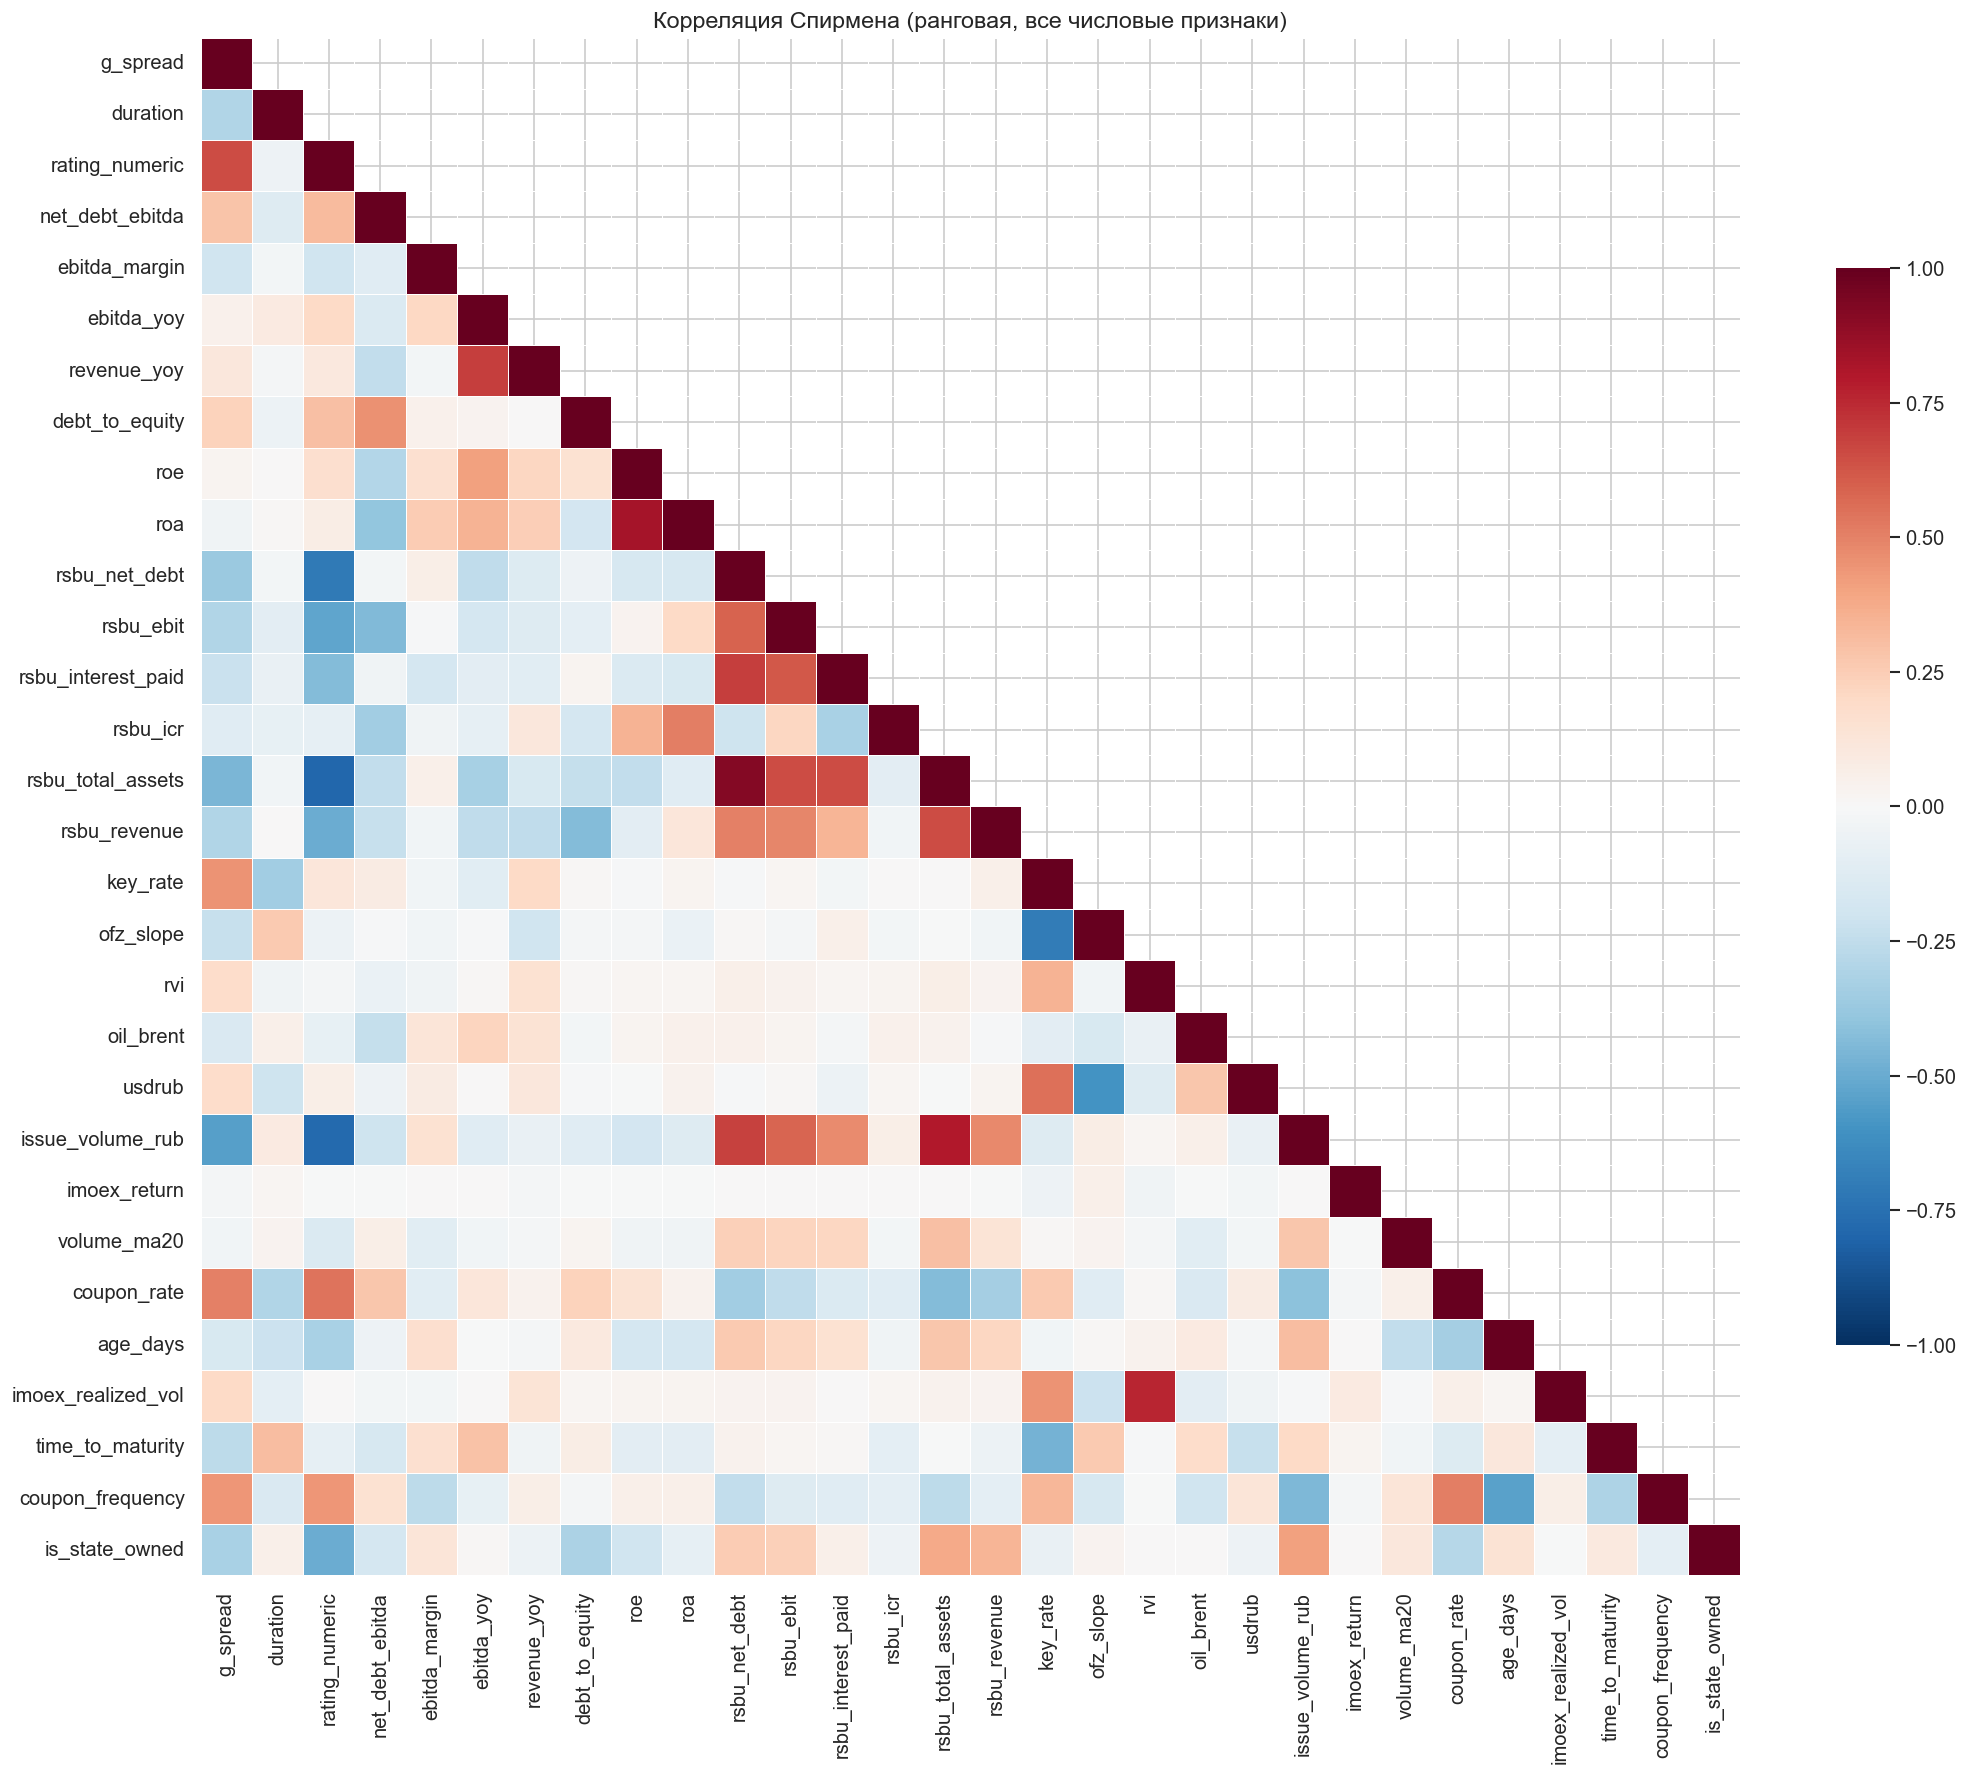

In [18]:
# Spearman
spearman = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(spearman, dtype=bool), k=1)
sns.heatmap(spearman, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False, fmt='.2f',
            linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Корреляция Спирмена (ранговая, все числовые признаки)', fontsize=14)
fig.tight_layout()
savefig('corr_spearman')
plt.show()

In [19]:
# Highlight problematic pairs
problem_pairs = [
    ('net_debt_ebitda', 'rsbu_icr', 'Leverage vs ICR'),
    ('oil_brent', 'usdrub', 'Oil vs USD/RUB'),
    ('key_rate', 'ofz_slope', 'Key rate vs OFZ slope'),
]

print('Проблемные пары (высокая корреляция -> мультиколлинеарность):')
print(f'{"Пара":<35} {"Pearson":>10} {"Spearman":>10}')
print('-' * 57)
for c1, c2, desc in problem_pairs:
    if c1 in pearson.columns and c2 in pearson.columns:
        p = pearson.loc[c1, c2]
        s = spearman.loc[c1, c2]
        print(f'{desc:<35} {p:>10.3f} {s:>10.3f}')
    else:
        print(f'{desc:<35}   (columns not found)')

Проблемные пары (высокая корреляция -> мультиколлинеарность):
Пара                                   Pearson   Spearman
---------------------------------------------------------
Leverage vs ICR                         -0.100     -0.349
Oil vs USD/RUB                           0.031      0.281
Key rate vs OFZ slope                   -0.716     -0.698


## 8. VIF-анализ (Variance Inflation Factor)

In [20]:
# VIF on Tier 1 numeric features
vif_cols = TIER1_NUMERIC.copy()
vif_df = df[vif_cols].dropna().copy()

print(f'Rows after dropna: {len(vif_df):,} (из {len(df):,})')

# Standardize for numeric stability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
vif_scaled = pd.DataFrame(
    scaler.fit_transform(vif_df),
    columns=vif_cols
)

vif_results = pd.DataFrame({
    'feature': vif_cols,
    'VIF': [variance_inflation_factor(vif_scaled.values, i)
            for i in range(len(vif_cols))]
})
vif_results['VIF'] = vif_results['VIF'].round(2)
vif_results['concerning'] = vif_results['VIF'].apply(
    lambda x: 'VIF > 10' if x > 10 else ('5 < VIF < 10' if x > 5 else 'OK')
)
vif_results = vif_results.sort_values('VIF', ascending=False).reset_index(drop=True)

print('\nVIF для Tier 1 числовых признаков:')
vif_results

Rows after dropna: 59,713 (из 295,569)



VIF для Tier 1 числовых признаков:


,feature,VIF,concerning
0,key_rate,2.73,OK
1,ofz_slope,2.66,OK
2,usdrub,1.93,OK
3,rating_numeric,1.54,OK
4,oil_brent,1.53,OK
5,issue_volume_rub,1.47,OK
6,rvi,1.41,OK
7,duration,1.11,OK
8,net_debt_ebitda,1.11,OK


Saved: /repo/notebooks/figures/02_vif_tier1.png


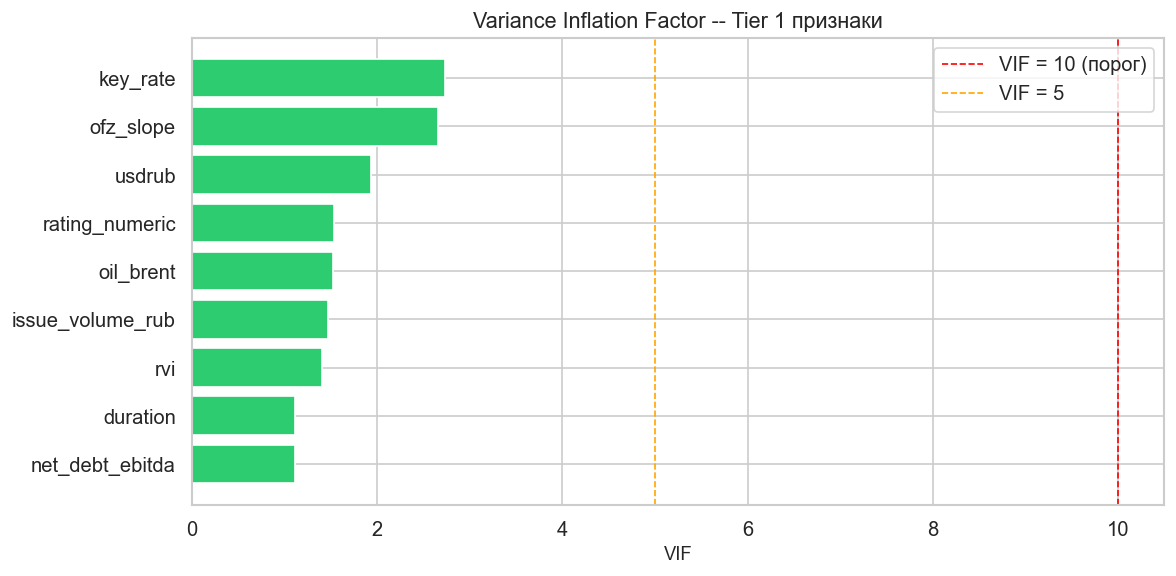

In [21]:
# VIF bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_results['VIF']]
ax.barh(vif_results['feature'], vif_results['VIF'], color=colors, edgecolor='white')
ax.axvline(10, color='red', ls='--', lw=1, label='VIF = 10 (порог)')
ax.axvline(5, color='orange', ls='--', lw=1, label='VIF = 5')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor -- Tier 1 признаки')
ax.legend()
ax.invert_yaxis()
fig.tight_layout()
savefig('vif_tier1')
plt.show()

## 9. Сравнение Cbonds vs РСБУ-метрик

Наблюдений с обоими источниками: 40,914
Уникальных облигаций: 175
Saved: /repo/notebooks/figures/02_cbonds_vs_rsbu.png


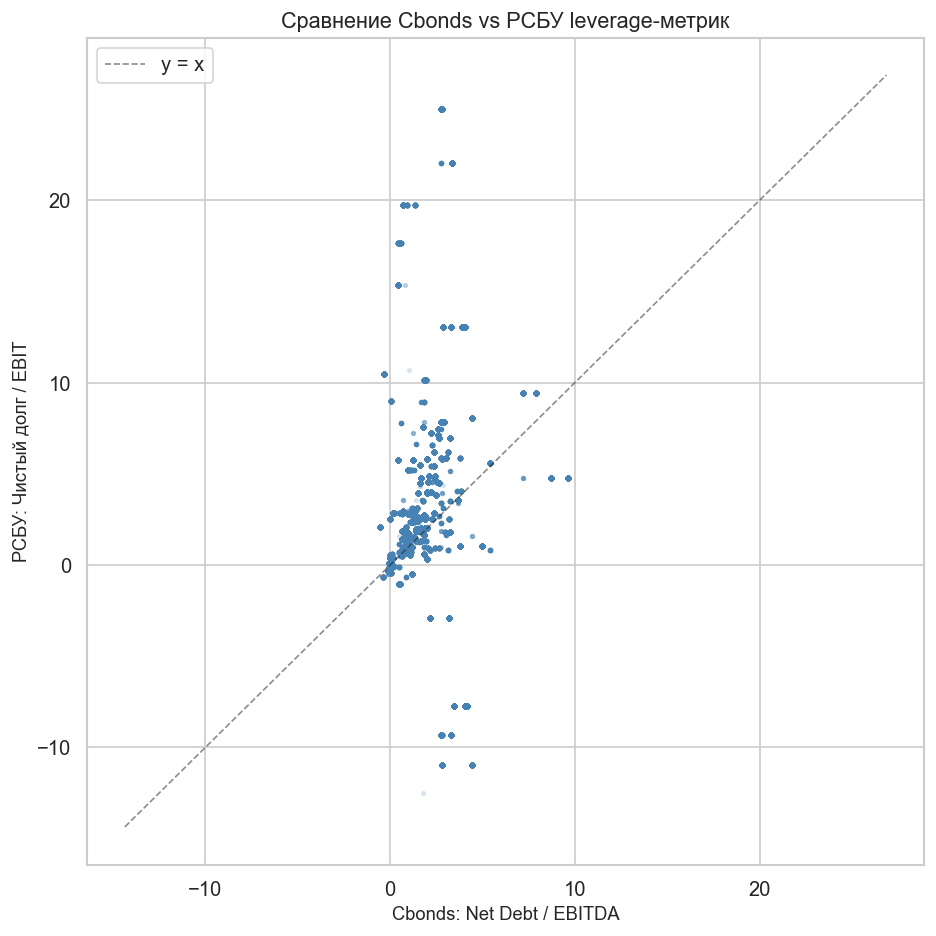

In [22]:
# Subset with both Cbonds net_debt_ebitda and RSBU components
df_cmp = df.dropna(subset=['net_debt_ebitda', 'rsbu_net_debt', 'rsbu_ebit']).copy()
df_cmp = df_cmp[df_cmp['rsbu_ebit'] != 0].copy()  # avoid division by zero
df_cmp['rsbu_nd_ebit'] = df_cmp['rsbu_net_debt'] / df_cmp['rsbu_ebit']

print(f'Наблюдений с обоими источниками: {len(df_cmp):,}')
print(f'Уникальных облигаций: {df_cmp["isin"].nunique()}')

# Clip extreme outliers for visualization
q_low, q_high = df_cmp['rsbu_nd_ebit'].quantile([0.01, 0.99])
q_low_c, q_high_c = df_cmp['net_debt_ebitda'].quantile([0.01, 0.99])
mask_vis = (
    (df_cmp['rsbu_nd_ebit'].between(q_low, q_high)) &
    (df_cmp['net_debt_ebitda'].between(q_low_c, q_high_c))
)
df_vis = df_cmp[mask_vis].copy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_vis['net_debt_ebitda'], df_vis['rsbu_nd_ebit'],
           s=5, alpha=0.15, color='steelblue', rasterized=True)

# Diagonal
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, 'k--', lw=1, alpha=0.5, label='y = x')

ax.set_xlabel('Cbonds: Net Debt / EBITDA')
ax.set_ylabel('РСБУ: Чистый долг / EBIT')
ax.set_title('Сравнение Cbonds vs РСБУ leverage-метрик')
ax.legend()
fig.tight_layout()
savefig('cbonds_vs_rsbu')
plt.show()

In [23]:
# Correlation & MAE
corr_p = df_cmp['net_debt_ebitda'].corr(df_cmp['rsbu_nd_ebit'])
corr_s = df_cmp['net_debt_ebitda'].corr(df_cmp['rsbu_nd_ebit'], method='spearman')
mae = (df_cmp['net_debt_ebitda'] - df_cmp['rsbu_nd_ebit']).abs().median()

print(f'Pearson корреляция:  {corr_p:.3f}')
print(f'Spearman корреляция: {corr_s:.3f}')
print(f'Медианная MAE:       {mae:.2f}')
print()
print('Примечание: Cbonds использует EBITDA, РСБУ -- EBIT. '
      'Различия ожидаемы из-за разницы в стандартах и агрегации.')

Pearson корреляция:  0.041
Spearman корреляция: 0.265
Медианная MAE:       2.00

Примечание: Cbonds использует EBITDA, РСБУ -- EBIT. Различия ожидаемы из-за разницы в стандартах и агрегации.


## 10. Выводы

### Распределение целевой переменной
- G-spread имеет **правостороннюю асимметрию** (среднее > медианы): большинство облигаций торгуются с умеренным спредом, но есть длинный правый хвост.
- Логарифмическое преобразование может быть полезно для моделирования (более симметричное распределение).
- Присутствуют наблюдения с отрицательным или нулевым спредом -- требуется внимание при log-трансформации.

### Групповые эффекты
- **Рейтинг:** G-spread монотонно растет с ухудшением кредитного рейтинга -- ключевой признак.
- **Сектор:** существенная дифференциация между секторами (гос. финансы vs строительство).
- **Госсобственность:** государственные эмитенты торгуются с заметно меньшим спредом -- implicit government support.
- **Дюрация:** нелинейная связь; корзина 5+ лет показывает более широкие спреды.

### Временная динамика
- Четко видны кризисные эпизоды: COVID-2020, геополитический шок 2022, цикл повышения ставки 2023-2024.
- G-spread коррелирует с ключевой ставкой и RVI (индекс волатильности).
- Расширение спредов между рейтинговыми классами в стрессовые периоды -- "flight to quality".

### Мультиколлинеарность
- Пары oil_brent / usdrub и key_rate / ofz_slope могут показать повышенный VIF.
- Для древесных моделей (CatBoost, XGBoost) VIF не критичен; для линейных моделей -- требуется отбор.
- net_debt_ebitda / rsbu_icr -- взаимодополняющие метрики, не полные дублики.

### Cbonds vs РСБУ
- Корреляция положительная, но не идеальная: разные стандарты (EBITDA vs EBIT), разная периодичность.
- РСБУ-данные можно использовать как резервный источник при отсутствии Cbonds-фундаменталов.
- MAE показывает систематическое расхождение -- нельзя просто подставлять одно вместо другого.

In [24]:
print('Notebook 02 complete. All figures saved to:', FIG_DIR)

Notebook 02 complete. All figures saved to: /repo/notebooks/figures
